In [1]:
import numpy as np
import matplotlib.pyplot as plt

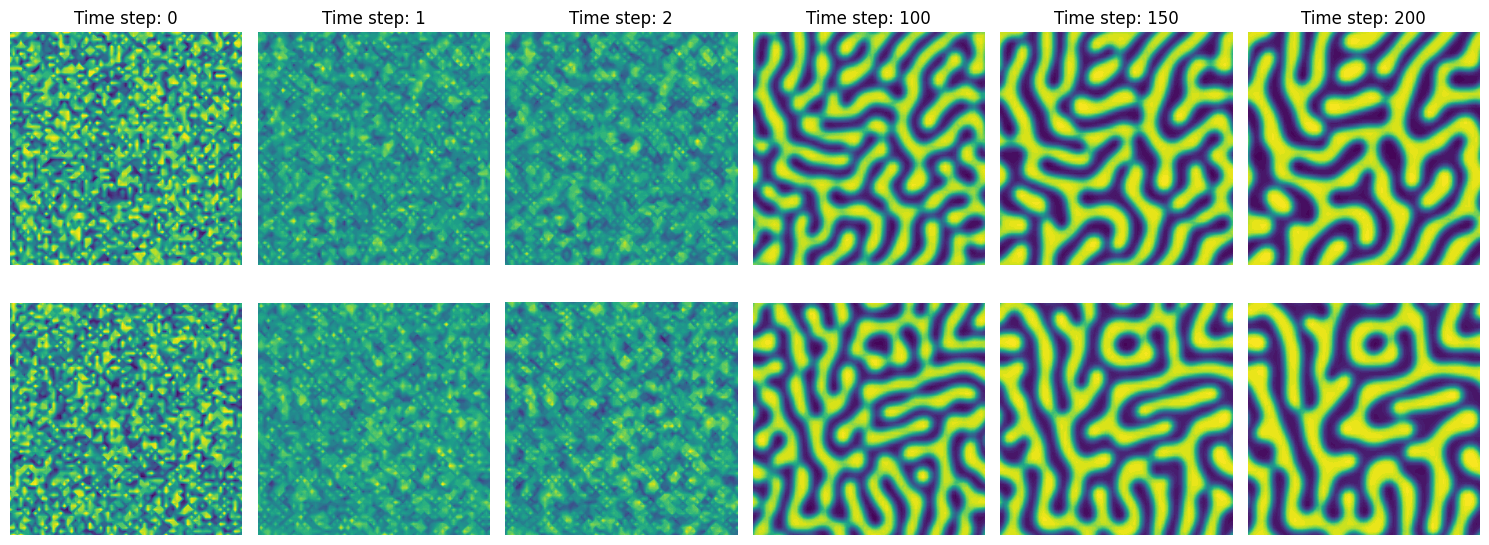

In [2]:
save_dir = "./data"
solutions = np.load(f"{save_dir}/train_valid/solutions_grid.npy")
mesh = np.load(f"{save_dir}/train_valid/mesh_grid_coords.npy")
mesh = np.transpose(mesh, (2, 0, 1))
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
tics = [0, 1, 2, 100, 150, 200]

fig, axes = plt.subplots(2, len(tics), figsize=(15, 6))
for i, tic in enumerate(tics):
    ax = axes[0, i]
    im = ax.contourf(meshx, meshy, solutions[0, tic, 0, ...],
                     levels=50, cmap='viridis')
    ax.set_title(f'Time step: {tic}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    # fig.colorbar(im, ax=ax)
    ax.set_aspect('equal')
    ax.set_axis_off()

    ax = axes[1, i]
    im = ax.contourf(meshx, meshy, solutions[1, tic, 0, ...],
                     levels=50, cmap='viridis')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    # fig.colorbar(im, ax=ax)
    ax.set_aspect('equal')
    ax.set_axis_off()
fig.tight_layout()

In [3]:
solutions.shape

(10, 201, 2, 65, 65)

In [4]:
from configs.train_debug import Configs
configs = Configs()
num_ics = 10
mesh = np.load("./data/train_valid/mesh_grid_coords.npy")
mesh = np.transpose(mesh, (2, 0, 1))
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
times = np.load("./data/train_valid/times.npy")
dt = times[1] - times[0]
num_times = times.shape[0]
solutions = np.load("./data/train_valid/solutions_grid.npy", allow_pickle=True)
Xs = np.zeros(
    ((num_times-1)*num_ics, 4, mesh.shape[1], mesh.shape[2])
) 
Ys = np.zeros(
    ((num_times-1)*num_ics, 2, mesh.shape[1], mesh.shape[2])
)

for i in range(num_ics):
    Xs[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, :-1, 0, :, :]  # phi
    Xs[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, :-1, 1, :, :]  # c
    # mesh_x_repeated = np.repeat(mesh[:, :, 0][np.newaxis, :, :], num_times-1, axis=0)
    # Xs[i*(num_times-1):(i+1)*(num_times-1), 2, :, :] = mesh_x_repeated / configs.Lc  # x
    # mesh_y_repeated = np.repeat(mesh[:, :, 1][np.newaxis, :, :], num_times-1, axis=0)
    # Xs[i*(num_times-1):(i+1)*(num_times-1), 3, :, :] = mesh_y_repeated / configs.Lc # y

    Ys[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, 1:, 0, :, :]  # phi at next time step
    Ys[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, 1:, 1, :, :]  # c
meshes_repeated = np.repeat(mesh[np.newaxis, :, :, :], Xs.shape[0], axis=0)
Xs[:, 2, :, :] = meshes_repeated[:, 0, :, :] / configs.Lc  # x
Xs[:, 3, :, :] = meshes_repeated[:, 1, :, :] / configs.Lc # y

-0.024978143411271747 0.02498688927255867 -0.04007069053634305 0.03416435654587119 4.509205969927509e-06 0.05411342943394076
-0.767365281825876 0.7662524207626391 -0.7970326684905261 0.796077385967039 1.5122207296408563e-05 0.048755959405571814
-1.0397302322893778 1.0168396436485971 -1.0403810100072817 1.018118258229069 6.91886879122805e-07 0.06554781611438992
-1.057073455105607 1.0462996546670524 -1.056889398671937 1.0459706669940574 1.0726114284542732e-06 0.07961379966116594


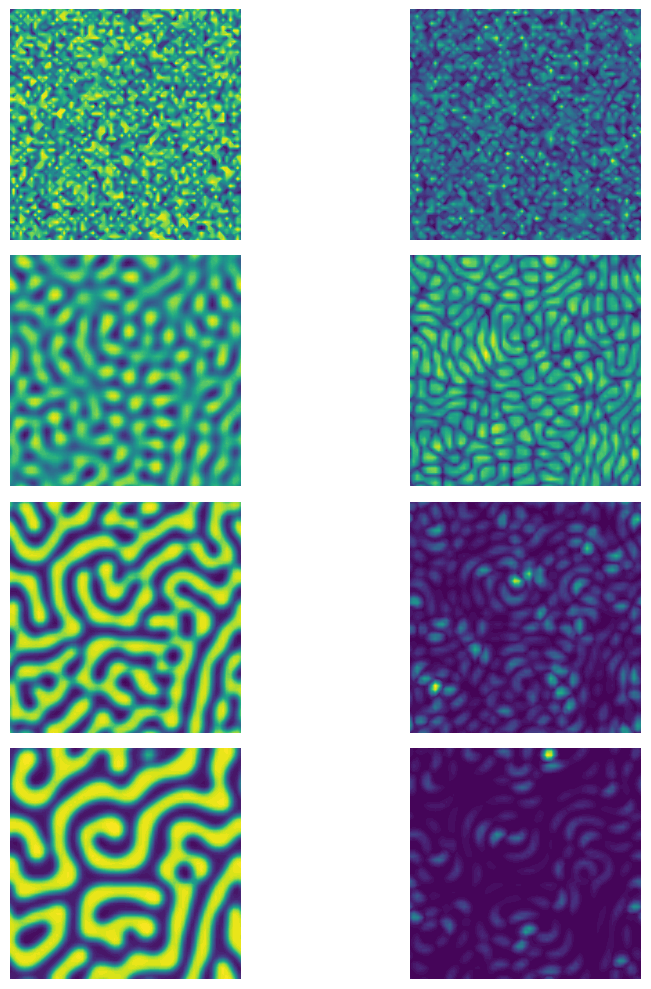

In [5]:
import matplotlib.pyplot as plt
ts = [0, 40, 99, 199]
fig, axes = plt.subplots(4, 2, figsize=(10, 10))
for idx, t in enumerate(ts):
    t += 400
    x = Xs[t, 0, :, :]
    y = Ys[t, 0, :, :]
    meshx = Xs[t, 2, :, :] * configs.Lc
    meshy = Xs[t, 3, :, :] * configs.Lc
    ax = axes[idx, 0]
    # im = ax.pcolormesh(meshx, meshy, x, cmap="coolwarm")
    ax.contourf(meshx, meshy, x, levels=50, cmap='viridis')
    ax.set_aspect('equal')
    ax.set_axis_off()

    ax = axes[idx, 1]
    diff = np.abs(y - x)
    # im = ax.pcolormesh(meshx, meshy, diff, cmap="coolwarm")
    ax.contourf(meshx, meshy, diff, levels=50, cmap='viridis')
    ax.set_aspect('equal')
    ax.set_axis_off()
    print(x.min(), x.max(), y.min(), y.max(), diff.min(), diff.max())
fig.tight_layout()


In [6]:
times = np.load(f"{save_dir}/train_valid/times.npy")
dt = times[1] - times[0]
dt

np.float64(5e-05)

In [7]:
np.savez(
    "./data/train_valid/dataset_2d_complete.npz",
    meshes=mesh/configs.Lc,
    times=times/configs.Tc,
    Xs=Xs,
    Ys=Ys,
)